# Ratio-CATE Learner Benchmark

Evaluation of meta-learners for ratio-based CATE estimation:
$$\tau(x) = \frac{E[Y|W=1,X]}{E[Y|W=0,X]}$$

## Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

from datasets import get_dataset, ALL_DATASETS
from learner import get_learner, ALL_LEARNER
from calibration import CalibratedCATELearner
from metrics import evaluate_predictions


## Configuration

In [ ]:
# Datasets to evaluate
DATASETS = ALL_DATASETS
# Learners to evaluate (calibrated variants are evaluated automatically in the loop)
LEARNER = list(ALL_LEARNER.keys())

# Number of runs per combination
N_RUNS = 100

# Base seed (each run uses BASE_SEED + run_idx)
BASE_SEED = 42

In [ ]:
print(f"Datasets: {DATASETS}")
print(f"Learners: {LEARNER}")
print(f"Runs per combination: {N_RUNS}")


## Run Benchmark

In [ ]:
# Resume from existing results if available
import os
if 'results' not in locals() or results is None:
    if os.path.exists('benchmark_results.csv'):
        df_existing = pd.read_csv('benchmark_results.csv')
        results = df_existing.to_dict('records')
        print(f"Loaded {len(results)} existing results from benchmark_results.csv")
    else:
        results = []

# Build set of already-completed (dataset, learner, seed) for fast lookup
done = {(r['dataset'], r['learner'], r['seed']) for r in results}
print(f"Skipping {len(done)} already-completed combinations")

for dataset_name in tqdm(DATASETS, desc='Datasets'):
    for run_idx in range(N_RUNS):
        seed = BASE_SEED + run_idx
        
        # Skip entire seed if all learners already done
        all_done = all(
            (dataset_name, ln, seed) in done and (dataset_name, ln + '_cal', seed) in done
            for ln in LEARNER
        )
        if all_done:
            continue
        
        # Load dataset with current seed
        data = get_dataset(dataset_name, random_state=seed)
        
        # Use true propensity when available (RCTs and synthetic)
        prop_train = data.propensity_true_train
        prop_test = data.propensity_true_test
        
        for learner_name in LEARNER:
            if (dataset_name, learner_name, seed) in done:
                continue

            # DR-Q-Simple requires known propensity — skip on observational datasets
            if 'simple' in learner_name and prop_train is None:
                continue

            try:
                # Fit base learner once
                learner = get_learner(learner_name, random_state=seed)
                learner.fit(data.X_train, data.W_train, data.Y_train, propensity=prop_train)
                tau_pred = learner.predict(data.X_test, propensity=prop_test)
                
                # Evaluate base learner
                metrics = evaluate_predictions(
                    tau_pred=tau_pred,
                    W=data.W_test,
                    Y=data.Y_test,
                    tau_true=data.tau_true_test if data.tau_true is not None else None
                )
                results.append({
                    'dataset': dataset_name,
                    'learner': learner_name,
                    'run': run_idx,
                    'seed': seed,
                    **metrics
                })
                done.add((dataset_name, learner_name, seed))

                # Calibrate same fitted learner (no refit of base learner)
                cal = CalibratedCATELearner(learner, random_state=seed)
                cal.fit(data.X_train, data.W_train, data.Y_train, propensity=prop_train)
                tau_cal = cal.predict(data.X_test, propensity=prop_test)

                metrics_cal = evaluate_predictions(
                    tau_pred=tau_cal,
                    W=data.W_test,
                    Y=data.Y_test,
                    tau_true=data.tau_true_test if data.tau_true is not None else None
                )
                results.append({
                    'dataset': dataset_name,
                    'learner': learner_name + '_cal',
                    'run': run_idx,
                    'seed': seed,
                    **metrics_cal
                })
                done.add((dataset_name, learner_name + '_cal', seed))
            
            except Exception as e:
                print(f"\nError with {learner_name} on {dataset_name} (seed {seed}): {str(e)}")
                continue

    # Save checkpoint after each dataset
    pd.DataFrame(results).to_csv('benchmark_results.csv', index=False)

df_results = pd.DataFrame(results)
df_results.head(10)

## Results Summary

In [ ]:
# Aggregate metrics by learner and dataset
metric_cols = ['qini', 'uplift@0.1', 'uplift@0.2', 'uplift@0.3', 
               'cal_error', 'cal_slope', 'rmse', 'rmse_log', 'mae', 'spearman', 'pearson']
metric_cols = [c for c in metric_cols if c in df_results.columns]

summary = df_results.groupby(['dataset', 'learner'])[metric_cols].agg(['mean', 'std']).round(4)
summary

## Export Results

In [ ]:
# Save raw results
df_results.to_csv('benchmark_results.csv', index=False)

# Save summary
summary.to_csv('benchmark_summary.csv')

print("Results saved to benchmark_results.csv and benchmark_summary.csv")

## Visualizations

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from datasets import RCT_DATASETS, OBS_DATASETS, SEMI_SYNTHETIC_DATASETS

# --- Dataset groups ---
RCT_ALL = RCT_DATASETS + SEMI_SYNTHETIC_DATASETS
ALL_DATASETS = RCT_ALL + OBS_DATASETS

# --- Learner definitions ---
PLOT_LEARNERS = {
    's':              'S',
    't':              'T',
    'q':              'Q',
    'q_simple':       'Q-Simple',
    'x':              'X',
    'drq_direct_cal': 'DR-Q',
    'drq_log_cal':    'DR-Q log',
    'drq_simple_direct_cal': 'DR-Q-Simple',
    'drq_simple_log_cal':    'DR-Q-Simple log',
    'drt_direct_cal': 'DR-T',
    'drt_log_cal':    'DR-T log',
    'drs_direct_cal': 'DR-S',
    'drs_log_cal':    'DR-S log',
}

BASE_LEARNERS = {k.replace('_cal', ''): v for k, v in PLOT_LEARNERS.items()}

LEARNER_ORDER = [
    'S', 'T', 'Q', 'Q-Simple', 'X',
    'DR-Q', 'DR-Q log', 'DR-Q-Simple', 'DR-Q-Simple log',
    'DR-T', 'DR-T log', 'DR-S', 'DR-S log',
]

LEARNER_FAMILY = {
    'S': 'plug-in', 'T': 'plug-in',
    'Q': 'Q-family', 'Q-Simple': 'Q-family', 'X': 'plug-in',
    'DR-Q': 'Q-family', 'DR-Q log': 'Q-family',
    'DR-Q-Simple': 'Q-family', 'DR-Q-Simple log': 'Q-family',
    'DR-T': 'DR-S/T', 'DR-T log': 'DR-S/T',
    'DR-S': 'DR-S/T', 'DR-S log': 'DR-S/T',
}

FAMILY_COLORS  = {'plug-in': '#4C72B0', 'Q-family': '#DD8452', 'DR-S/T': '#55A868'}
FAMILY_MARKERS = {'plug-in': 'o',       'Q-family': 's',        'DR-S/T': 'D'}

DATASET_SHORT = {
    'hillstrom_visit': 'H(Vis)', 'hillstrom_conversion': 'H(Conv)',
    'criteo': 'Criteo', 'megafon': 'MegaFon', 'x5_retail': 'X5',
    'lenta': 'Lenta', 'twins': 'Twins',
    'lalonde': 'LaLonde', 'rhc': 'RHC',
    'cattaneo': 'Cattaneo', 'nhefs': 'NHEFS', 'jtpa': 'JTPA',
}

plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# --- Prepare plotting dataframe ---
df_plot = df_results[df_results['learner'].isin(PLOT_LEARNERS)].copy()
df_plot['label']  = df_plot['learner'].map(PLOT_LEARNERS)
df_plot['family'] = df_plot['label'].map(LEARNER_FAMILY)

# --- Per-dataset mean Qini (mean over 100 seeds) ---
qini_matrix = df_plot.groupby(['label', 'dataset'])['qini'].mean().unstack('dataset')

# --- Per-dataset mean CalError (mean over 100 seeds, best of base/cal) ---
# For each learner, take min(base, calibrated) CalError per dataset
cal_rows = []
for base_key, label in BASE_LEARNERS.items():
    cal_key = base_key + '_cal'
    for ds in ALL_DATASETS:
        base_sub = df_results[(df_results['learner'] == base_key) &
                               (df_results['dataset'] == ds)]
        cal_sub  = df_results[(df_results['learner'] == cal_key) &
                               (df_results['dataset'] == ds)]
        if len(base_sub) == 0:
            continue
        base_err = base_sub['cal_error'].mean()
        cal_err  = cal_sub['cal_error'].mean() if len(cal_sub) > 0 else base_err
        cal_rows.append({'label': label, 'dataset': ds,
                         'cal_error': min(base_err, cal_err)})

cal_matrix = pd.DataFrame(cal_rows).pivot(index='label', columns='dataset',
                                           values='cal_error')

# --- Ratio to best: Qini (<= 1, 1 = best ranker; signed, can be negative) ---
dataset_best_qini = qini_matrix.max(axis=0)
qini_ratio = qini_matrix.divide(dataset_best_qini, axis=1)

# --- Ratio to best: CalError (>= 1, 1 = best calibrated on that dataset) ---
dataset_best_cal = cal_matrix.min(axis=0)
cal_ratio = cal_matrix.divide(dataset_best_cal, axis=1)

# --- Helper: summary stats ---
def learner_summary(matrix, datasets):
    sub = matrix.reindex(columns=datasets).dropna(axis=1, how='all')
    return pd.DataFrame({'mean': sub.mean(axis=1), 'std': sub.std(axis=1)})

rct_qini_ratio_summary = learner_summary(qini_ratio, RCT_ALL)
obs_qini_ratio_summary = learner_summary(qini_ratio, OBS_DATASETS)
rct_cal_ratio_summary  = learner_summary(cal_ratio, RCT_ALL)
obs_cal_ratio_summary  = learner_summary(cal_ratio, OBS_DATASETS)

# --- Helper: scatter plot ---
from adjustText import adjust_text

def scatter_panel(ax, summary, title, ylabel):
    for label, row in summary.iterrows():
        fam = LEARNER_FAMILY[label]
        ax.scatter(row['std'], row['mean'],
                   c=FAMILY_COLORS[fam], marker=FAMILY_MARKERS[fam],
                   s=100, zorder=5, edgecolors='black', linewidth=0.5)
        ax.annotate(label, (row['std'], row['mean']),
                    textcoords="offset points",
                    xytext=(0, 7),
                    fontsize=9,
                    ha='center', va='bottom', zorder=6)
    ax.set_xlabel(r'Std across datasets')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)



print("Cell 1 complete.")
print(f"Qini ratio range: [{qini_ratio.min().min():.3f}, {qini_ratio.max().max():.3f}]")
print(f"Cal ratio range: [{cal_ratio.min().min():.3f}, {cal_ratio.max().max():.3f}]")

Cell 1 complete.
Qini ratio range: [-0.549, 1.000]
Cal ratio range: [1.000, 3.820]


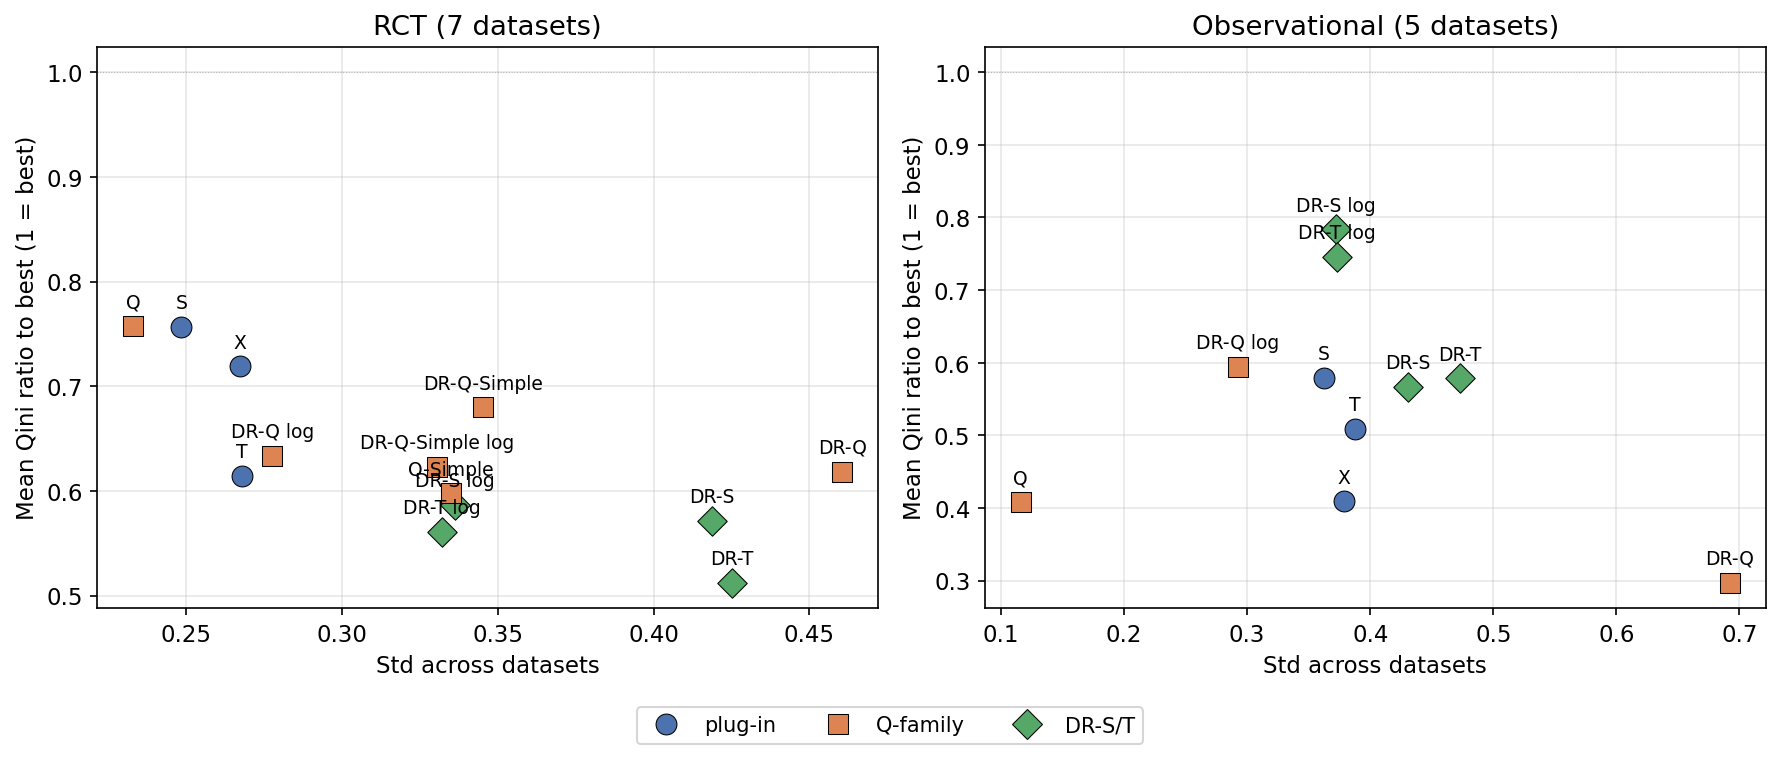

                     mean       std
label                              
DR-Q             0.618439  0.460548
DR-Q log         0.633732  0.277744
DR-Q-Simple      0.679870  0.345381
DR-Q-Simple log  0.622991  0.330547
DR-S             0.571343  0.418694
DR-S log         0.586864  0.336354
DR-T             0.512340  0.425066
DR-T log         0.560633  0.332088
Q                0.757453  0.233089
Q-Simple         0.597758  0.335168
S                0.756427  0.248592
T                0.614736  0.267973
X                0.719041  0.267359
                     mean       std
label                              
DR-Q             0.297076  0.692325
DR-Q log         0.594505  0.292370
DR-Q-Simple           NaN       NaN
DR-Q-Simple log       NaN       NaN
DR-S             0.567110  0.430364
DR-S log         0.783661  0.371878
DR-T             0.578312  0.472639
DR-T log         0.745977  0.372634
Q                0.408254  0.115848
Q-Simple              NaN       NaN
S                0.579226  0

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

scatter_panel(ax1, rct_qini_ratio_summary,
              f'RCT ({len(RCT_ALL)} datasets)',
              'Mean Qini ratio to best (1 = best)')
scatter_panel(ax2, obs_qini_ratio_summary,
              f'Observational ({len(OBS_DATASETS)} datasets)',
              'Mean Qini ratio to best (1 = best)')

# Reference line at 1
for ax in [ax1, ax2]:
    ax.axhline(1, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

legend_elements = [
    Line2D([0], [0], marker=FAMILY_MARKERS[f], color='w',
           markerfacecolor=FAMILY_COLORS[f], markersize=10,
           markeredgecolor='black', markeredgewidth=0.5, label=f)
    for f in FAMILY_COLORS
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig_qini_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print(rct_qini_ratio_summary)
print(obs_qini_ratio_summary)

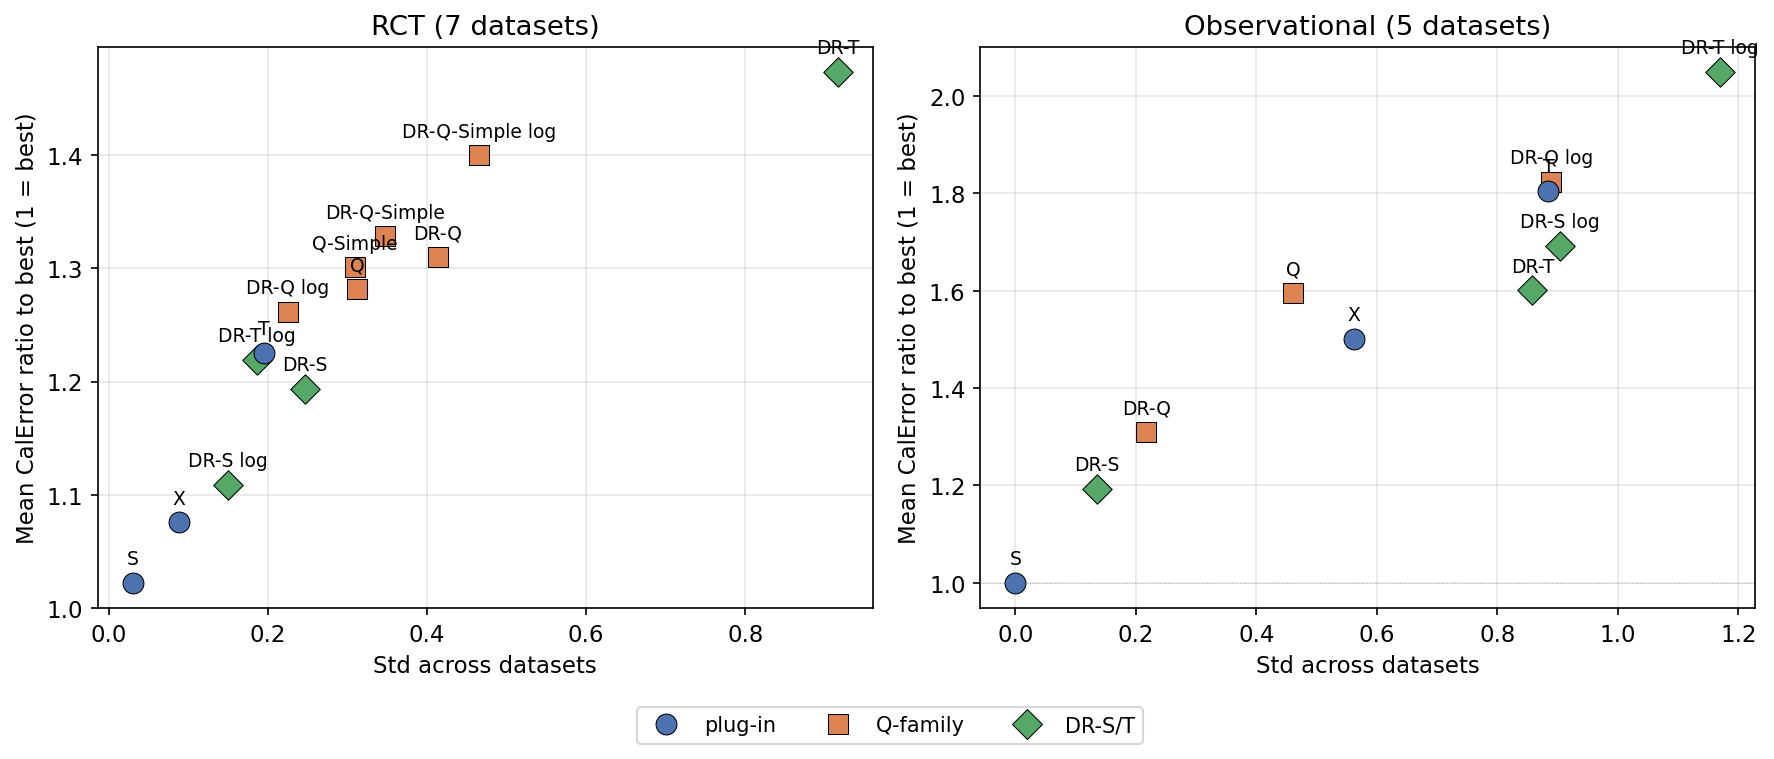

                     mean       std
label                              
DR-Q             1.309790  0.413824
DR-Q log         1.261729  0.225287
DR-Q-Simple      1.328310  0.347233
DR-Q-Simple log  1.399802  0.464993
DR-S             1.193898  0.246804
DR-S log         1.108993  0.149866
DR-T             1.473283  0.915934
DR-T log         1.219509  0.186312
Q                1.281800  0.312083
Q-Simple         1.300895  0.308953
S                1.022382  0.030185
T                1.225306  0.195344
X                1.075640  0.088028
                     mean       std
label                              
DR-Q             1.309381  0.217402
DR-Q log         1.823334  0.889527
DR-Q-Simple           NaN       NaN
DR-Q-Simple log       NaN       NaN
DR-S             1.193264  0.134960
DR-S log         1.692585  0.903845
DR-T             1.600633  0.858039
DR-T log         2.049300  1.169870
Q                1.595132  0.460718
Q-Simple              NaN       NaN
S                1.000000  0

In [31]:
# Cell: Figure — Calibration ratio to Best (RCT / Observational)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

scatter_panel(ax1, rct_cal_ratio_summary,
              f'RCT ({len(RCT_ALL)} datasets)',
              'Mean CalError ratio to best (1 = best)')
scatter_panel(ax2, obs_cal_ratio_summary,
              f'Observational ({len(OBS_DATASETS)} datasets)',
              'Mean CalError ratio to best (1 = best)')

# Reference line at 1
for ax in [ax1, ax2]:
    ax.axhline(1, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

legend_elements = [
    Line2D([0], [0], marker=FAMILY_MARKERS[f], color='w',
           markerfacecolor=FAMILY_COLORS[f], markersize=10,
           markeredgecolor='black', markeredgewidth=0.5, label=f)
    for f in FAMILY_COLORS
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig_cal_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print(rct_cal_ratio_summary)
print(obs_cal_ratio_summary)

In [ ]:
def make_qini_table(datasets, caption, label):
    sub = df_plot[df_plot['dataset'].isin(datasets)]
    means = sub.groupby(['label', 'dataset'])['qini'].mean().unstack('dataset')
    sems  = sub.groupby(['label', 'dataset'])['qini'].sem().unstack('dataset')

    ds_order = [d for d in datasets if d in means.columns]
    ds_headers = ' & '.join(DATASET_SHORT.get(d, d) for d in ds_order)
    best_per_ds = {d: means[d].idxmax() for d in ds_order}
    best_mean = means.reindex(columns=ds_order).mean(axis=1).idxmax()

    # Per-dataset best Qini across learners (for ratio-based sigma_D)
    row_best = means.reindex(columns=ds_order).max(axis=0)

    col_spec = 'l | ' + 'r' * len(ds_order) + ' | r r'
    lines = []
    lines.append(r'\begin{table}[t]')
    lines.append(r'\centering')
    lines.append(r'\footnotesize')
    lines.append(f'\\caption{{{caption}}}')
    lines.append(f'\\label{{{label}}}')
    lines.append(r'\setlength{\tabcolsep}{3pt}')
    lines.append(f'\\begin{{tabular}}{{{col_spec}}}')
    lines.append(r'\hline')
    lines.append(f'Learner & {ds_headers} & $\\bar{{Q}}$ & $\\sigma_D$ \\\\')
    lines.append(r'\hline')

    for i, lname in enumerate(LEARNER_ORDER):
        if i == 5:
            lines.append(r'\hline')
        if lname not in means.index:
            continue
        row_m = means.loc[lname].reindex(ds_order)
        row_s = sems.loc[lname].reindex(ds_order)
        mean_q = row_m.mean()
        # sigma_D on the ratio scale: std across datasets of Q_{l,d} / max_{l'} Q_{l',d}
        row_r = row_m / row_best
        sigma_d = row_r.std()

        def fmt(v, bold):
            s = f'{v:.3f}' if v >= 0 else f'$-${abs(v):.3f}'
            return f'\\textbf{{{s}}}' if bold else s

        vals = [fmt(row_m[d], best_per_ds.get(d) == lname) for d in ds_order]
        mean_s = fmt(mean_q, lname == best_mean)
        se_vals = [f'\\scriptsize({row_s[d]:.3f})' for d in ds_order]
        sp = '[2pt]' if i < len(LEARNER_ORDER) - 1 else ''

        lines.append(f'{lname}')
        lines.append(f' & {" & ".join(vals)} & {mean_s} & {sigma_d:.3f} \\\\')
        lines.append(f' & {" & ".join(se_vals)} & & \\\\{sp}')

    # Dataset-mean row (mean across all learners per dataset)
    ds_means = means.reindex(columns=ds_order).mean(axis=0)
    ds_mean_vals = ' & '.join(f'{ds_means[d]:.3f}' for d in ds_order)
    lines.append(r'\hline')
    lines.append(f'\\textit{{Dataset mean}} & {ds_mean_vals} & & \\\\')
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


# RCT table
print(make_qini_table(
    RCT_ALL,
    'Qini coefficient on RCT datasets (mean over 100 seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}. $\sigma_D$ is the cross-dataset standard '
    r"deviation of the per-dataset ratio $Q_{l,d}/\max_{l'} Q_{l',d}$. "
    r'Bottom row: mean across all learners per dataset.',
    'tab:results-rct'))

print('\n\n')

# Observational table
print(make_qini_table(
    OBS_DATASETS,
    'Qini coefficient on observational datasets (mean over 100 seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}. $\sigma_D$ is the cross-dataset standard '
    r"deviation of the per-dataset ratio $Q_{l,d}/\max_{l'} Q_{l',d}$. "
    r'Bottom row: mean across all learners per dataset.',
    'tab:results-obs'))


In [ ]:
def make_cal_table():
    pairs = [
        ('drq_direct',        'DR-Q'),
        ('drq_log',           'DR-Q log'),
        ('drq_simple_direct', 'DR-Q-Simple'),
        ('drq_simple_log',    'DR-Q-Simple log'),
        ('drt_direct',        'DR-T'),
        ('drt_log',           'DR-T log'),
        ('drs_direct',        'DR-S'),
        ('drs_log',           'DR-S log'),
        None,
        ('s',        'S-Learner'),
        ('t',        'T-Learner'),
        ('q',        'Q-Learner'),
        ('q_simple', 'Q-Simple'),
        ('x',        'X-Learner'),
    ]
    rct_only = {'drq_simple_direct', 'drq_simple_log', 'q_simple'}

    lines = []
    lines.append(r'\begin{table}[h]')
    lines.append(r'\centering')
    lines.append(r'\caption{Effect of post-hoc log-linear recalibration. '
                 r'DR-Q-Simple and Q-Simple: 7 RCT datasets only. '
                 r'Calibration is rank-preserving: $\Delta$\,Qini $= 0$.}')
    lines.append(r'\label{tab:calibration}')
    lines.append(r'\setlength{\tabcolsep}{6pt}')
    lines.append(r'\begin{tabular}{lrrr}')
    lines.append(r'\hline')
    lines.append(r'Learner & CalError (base) & CalError (cal.) & $\Delta$ \\')
    lines.append(r'\hline')

    for item in pairs:
        if item is None:
            lines.append(r'\hline')
            continue
        base_key, name = item
        cal_key = base_key + '_cal'
        ds = RCT_ALL if base_key in rct_only else ALL_DATASETS
        base_sub = df_results[(df_results['learner'] == base_key) &
                               (df_results['dataset'].isin(ds))]
        cal_sub  = df_results[(df_results['learner'] == cal_key) &
                               (df_results['dataset'].isin(ds))]
        if len(base_sub) == 0:
            continue
        base_err = base_sub['cal_error'].mean()
        cal_err  = cal_sub['cal_error'].mean() if len(cal_sub) > 0 else float('nan')
        delta = (cal_err - base_err) / base_err * 100

        # Format CalError as multiplicative factor (e.g. 2.70x)
        base_s = f'{base_err:.2f}$\\times$'
        cal_s  = f'{cal_err:.2f}$\\times$'

        if delta < -0.5:
            delta_s = f'$-${abs(delta):.0f}\\%'
        elif delta > 0.5:
            delta_s = f'$+${delta:.0f}\\%'
        else:
            delta_s = r'$\phantom{+}$0\%'

        lines.append(f'{name} & {base_s} & {cal_s} & {delta_s} \\\\')

    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

print(make_cal_table())


In [ ]:
def make_cal_table_per_dataset(datasets, caption, label):
    """CalError table structured like the Qini table: per-dataset columns, mean, sigma_D."""
    # Per-seed best(base, cal) CalError for each learner x dataset
    cal_rows_per_seed = []
    for base_key, lname in BASE_LEARNERS.items():
        cal_key = base_key + '_cal'
        for ds in datasets:
            base_sub = df_results[(df_results['learner'] == base_key) &
                                   (df_results['dataset'] == ds)]
            cal_sub  = df_results[(df_results['learner'] == cal_key) &
                                   (df_results['dataset'] == ds)]
            if len(base_sub) == 0:
                continue
            if len(cal_sub) > 0:
                merged = base_sub[['seed', 'cal_error']].merge(
                    cal_sub[['seed', 'cal_error']], on='seed',
                    suffixes=('_base', '_cal'))
                best = merged[['cal_error_base', 'cal_error_cal']].min(axis=1)
            else:
                best = base_sub['cal_error'].values
            for v in best:
                cal_rows_per_seed.append({'label': lname, 'dataset': ds, 'cal_error': v})

    df_cal = pd.DataFrame(cal_rows_per_seed)
    means = df_cal.groupby(['label', 'dataset'])['cal_error'].mean().unstack('dataset')
    sems  = df_cal.groupby(['label', 'dataset'])['cal_error'].sem().unstack('dataset')

    ds_order = [d for d in datasets if d in means.columns]
    ds_headers = ' & '.join(DATASET_SHORT.get(d, d) for d in ds_order)
    best_per_ds = {d: means[d].idxmin() for d in ds_order}
    best_mean_lname = means.reindex(columns=ds_order).mean(axis=1).idxmin()
    row_best = means.reindex(columns=ds_order).min(axis=0)

    col_spec = 'l | ' + 'r' * len(ds_order) + ' | r r'
    lines = []
    lines.append(r'\begin{table}[t]')
    lines.append(r'\centering')
    lines.append(r'\footnotesize')
    lines.append(f'\\caption{{{caption}}}')
    lines.append(f'\\label{{{label}}}')
    lines.append(r'\setlength{\tabcolsep}{3pt}')
    lines.append(f'\\begin{{tabular}}{{{col_spec}}}')
    lines.append(r'\hline')
    lines.append(f'Learner & {ds_headers} & $\\overline{{\\mathrm{{CE}}}}$ & $\\sigma_D$ \\\\')
    lines.append(r'\hline')

    learner_order_cal = ['S', 'T', 'Q', 'Q-Simple', 'X',
                         'DR-Q', 'DR-Q log', 'DR-Q-Simple', 'DR-Q-Simple log',
                         'DR-T', 'DR-T log', 'DR-S', 'DR-S log']

    for i, lname in enumerate(learner_order_cal):
        if i == 5:
            lines.append(r'\hline')
        if lname not in means.index:
            continue
        row_m = means.loc[lname].reindex(ds_order)
        row_s = sems.loc[lname].reindex(ds_order)
        mean_ce = row_m.mean()
        row_r = row_m / row_best
        sigma_d = row_r.std()

        def fmt(v, bold):
            if pd.isna(v):
                return '--'
            s = f'{v:.3f}'
            return f'\\textbf{{{s}}}' if bold else s

        vals = [fmt(row_m[d], best_per_ds.get(d) == lname) for d in ds_order]
        mean_s = fmt(mean_ce, lname == best_mean_lname)
        se_vals = [f'\\scriptsize({row_s[d]:.3f})' if not pd.isna(row_s[d])
                   else '\\scriptsize(--)' for d in ds_order]
        sp = '[2pt]' if i < len(learner_order_cal) - 1 else ''

        lines.append(f'{lname}')
        lines.append(f' & {" & ".join(vals)} & {mean_s} & {sigma_d:.3f} \\\\')
        lines.append(f' & {" & ".join(se_vals)} & & \\\\{sp}')

    ds_means = means.reindex(columns=ds_order).mean(axis=0)
    ds_mean_vals = ' & '.join(
        f'{ds_means[d]:.3f}' if not pd.isna(ds_means[d]) else '--'
        for d in ds_order)
    lines.append(r'\hline')
    lines.append(f'\\textit{{Dataset mean}} & {ds_mean_vals} & & \\\\')
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


# RCT calibration table
print(make_cal_table_per_dataset(
    RCT_ALL,
    r'CalError on RCT datasets (best of base/calibrated, mean over 100 seeds; '
    r'SE in parentheses). Best per column in \textbf{bold}. '
    r'$\sigma_D$ is the cross-dataset standard deviation of the per-dataset ratio '
    r"$\mathrm{CE}_{l,d}/\min_{l'} \mathrm{CE}_{l',d}$. "
    r'Bottom row: mean across all learners per dataset.',
    'tab:cal-rct'))

print('\n\n')

# Observational calibration table
print(make_cal_table_per_dataset(
    OBS_DATASETS,
    r'CalError on observational datasets (best of base/calibrated, mean over 100 seeds; '
    r'SE in parentheses). Best per column in \textbf{bold}. '
    r'$\sigma_D$ is the cross-dataset standard deviation of the per-dataset ratio '
    r"$\mathrm{CE}_{l,d}/\min_{l'} \mathrm{CE}_{l',d}$. "
    r'Bottom row: mean across all learners per dataset.',
    'tab:cal-obs'))
